# MACHINE LEARNING PROJECT

### Track T4 – Semi-Supervised Learning (SSL)
The objective of the project is to study and apply semi-supervised learning techniques to tabular data, analyzing how the limited availability of labels affects the performance of predictive models.

I'm interested in cybersecurity, so I chose the CSE-CIC-IDS2018 Intrusion CSVs (IDS 2018) dataset for the classification problem.

The dataset is based on logs from university servers, which recorded various DoS attacks during the publicly available period.
In total, there are 84 columns within this dataset, each of which corresponds to an entry in the IDS logging system that the Unversity of New Brunswick has in place.

Each entry in the dataset is originally labeled with multiple classes, such as Benign, FTP-BruteForce, and Other. To simplify the task and formulate it as a binary classification problem, I will consolidate all not-Benign labels into a single Malicious category. This way, the model will learn to distinguish between Benign and Malicious network traffic.

## Import libraries and models
I import the libraries and modules that we will need for the project.

In [1]:
# Imports
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.semi_supervised import SelfTrainingClassifier, LabelPropagation, LabelSpreading
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.exceptions import ConvergenceWarning
import dask.dataframe as dd
from dask_ml.preprocessing import StandardScaler, Categorizer
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
import os

# Global vars
RANDOM_STATE = 7

## Load and manipulate the dataset
I load the dataset using only a single large CSV instead of all the files. This simplifies processing, avoids mismatched type issues, and reduces memory usage.  
At the same time, I convert all labels that are not "Benign" into a single "Malicious" category.  
I use Dask that is a library which performs lazy loading to avoid loading the entire dataset into memory.

Label
Benign       7372557
Malicious     576191
Name: count, dtype: int32
Malicious/Benign: 7.82%



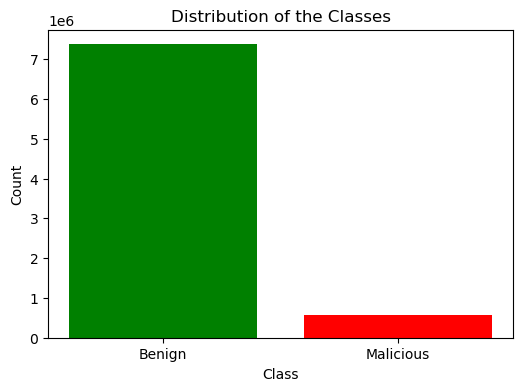

In [2]:
# Function to plot a graph
def showPlot(width, height, title, xDescription, yDescription, values, color):
    plt.figure(figsize = (width, height))
    plt.bar(values.index, values.values, color = color)
    plt.title(title)
    plt.xlabel(xDescription)
    plt.ylabel(yDescription)
    plt.show()

# Function to analyze a fetaure
def showCounts(dataset, feature, reindex, rename, width, height, title, xDescription, yDescription, color, showPlotFlag):
    counts = dataset[feature].value_counts(dropna = False).compute()
    if(rename != None):
        counts = counts.rename(index = rename)
    if(reindex != None):
        counts = counts.reindex(reindex)
    counts = counts.fillna(0)  
    counts = counts.astype(int)
    print(f"{counts}\nMalicious/Benign: {counts.get('Malicious', 0) / counts.get('Benign', 0):.2%}\n")
    if(showPlotFlag):
        showPlot(width, height, title, xDescription, yDescription, counts, color)

# Function to analyze dirty entries
def showPurity(dataset, showPlotFlag):
    dirty_entries_dt = dataset[dataset.isna().any(axis = 1)]
    dirty_entries = dirty_entries_dt.shape[0].compute()
    total_entries = dataset.shape[0].compute()
    clean_entries = total_entries - dirty_entries
    print(f"Entries that have at least 1 null feature value: {dirty_entries}\nTotal entries: {total_entries}\nPercentage of dirty entries: {dirty_entries / total_entries:.2%}\n")
    if(dirty_entries > 0):
        print(f"Analyzing dirty entries:\n{dirty_entries_dt['Label'].value_counts().compute()}\n")
    if(showPlotFlag):
        counts = pd.Series([clean_entries, dirty_entries], index = ["Clean Entries", "Dirty Entries"])
        showPlot(6, 4, "Clean Entries vs Dirty Entries", "Type", "Count", counts, ["skyblue", "brown"])    

dataset = dd.read_csv("Dataset/02-20-2018.csv", assume_missing = True)
dataset["Label"] = dataset["Label"].map(lambda x: "Malicious" if x != "Benign" else "Benign")
showCounts(dataset, "Label", ["Benign", "Malicious"], None, 6, 4, "Distribution of the Classes", "Class", "Count", ["green", "red"], True)

### Cleaning dirty entries
Now I check the entire dataset for entries with any missing feature values.

Entries that have at least 1 null feature value: 36767
Total entries: 7948748
Percentage of dirty entries: 0.46%

Analyzing dirty entries:
Label
Benign    36767
Name: count, dtype: int64



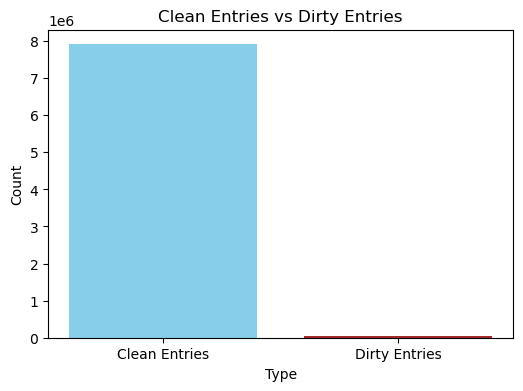

In [3]:
showPurity(dataset, True)

At this stage, I observe that entries with missing values represent less than 1% of the overall dataset. Removing features or attempting to impute missing values is not appropriate at this point, since most features are important for traffic analysis and will be further examined during the subsequent analysis phase. Moreover, filling missing values in network traffic data would be unreliable and could introduce noise, potentially distorting the underlying patterns. For these reasons, I will remove the incomplete entries from the dataset.

Additionally, as previously noted, the dataset is heavily imbalanced toward Benign traffic, as it contains a significantly larger number of such samples. Therefore, removing these already limited “dirty” entries, which are all classified as Benign, is further justified and does not negatively impact the representativeness of the dataset.

Entries that have at least 1 null feature value: 0
Total entries: 7911981
Percentage of dirty entries: 0.00%



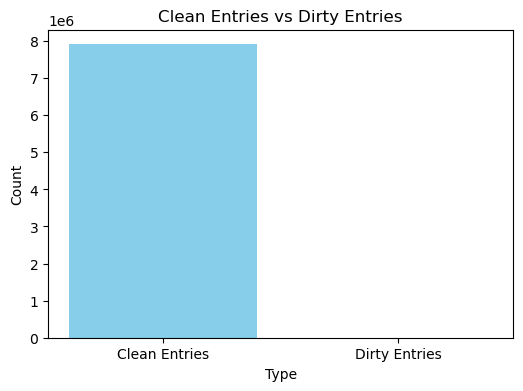

In [4]:
dataset = dataset.dropna()
showPurity(dataset, True)

### Analyzing infinite values
I analyze which features include infinite values across their entries.

In [5]:
numeric_features = dataset.select_dtypes(include=[np.number])
features_inf = list(numeric_features.columns[np.isinf(numeric_features).any(axis = 0)])
print(f"Features containing infinite values: {features_inf}")

Features containing infinite values: ['Flow Byts/s', 'Flow Pkts/s']


Now, I  check how many entries contain infinite values in those features.

Label
Benign       22686
Malicious        0
Name: count, dtype: int32
Malicious/Benign: 0.00%



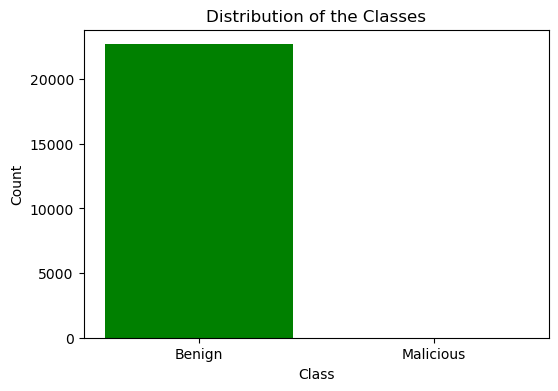

In [6]:
mask_inf = np.isinf(numeric_features).any(axis=1)
dataset_inf = dataset.loc[mask_inf]
showCounts(dataset_inf, "Label", ["Benign", "Malicious"], None, 6, 4, "Distribution of the Classes", "Class", "Count", ["green", "red"], True)

Since all detected samples containing infinite values belong to the benign class, and considering that the dataset is already strongly imbalanced, these entries can be safely removed without significantly affecting the representation of the minority (malicious) class.

Label
Benign       7313104
Malicious     576191
Name: count, dtype: int32
Malicious/Benign: 7.88%



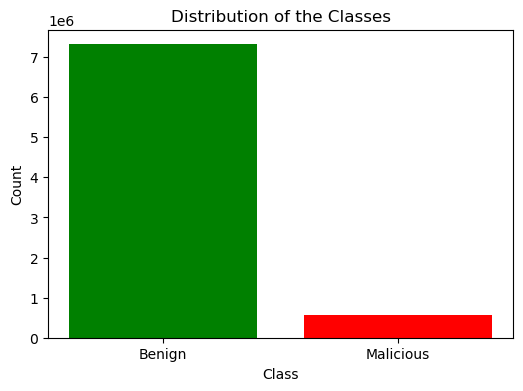

In [7]:
dataset = dataset.loc[~mask_inf]
showCounts(dataset, "Label", ["Benign", "Malicious"], None, 6, 4, "Distribution of the Classes", "Class", "Count", ["green", "red"], True)

### A priori feature removal
This dataset contains network traffic analysis data between devices and university servers, so it is necessary to carefully examine all the features available in each entry and remove those that are not relevant for analyzing future network traffic and making predictions, thereby essentially avoiding model overfitting.  
#### Showing features
Now I show the dataset features

In [8]:
print(f"Number of features: {dataset.shape[1]}\n{dataset.columns}")

Number of features: 84
Index(['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol',
       'Timestamp', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts',
       'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
       'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
       'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
       

Among all these features, I can surely remove the <span style="color:red"><b>Flow ID</b></span>, which is unique and therefore carries no weight in the learning process. The <span style="color:red"><b>destination IP</b></span> is not relevant because it only indicates which university server the packets are sent to and does not help distinguish malicious from benign traffic. Similarly, the <span style="color:red"><b>source IP</b></span> is not useful, as it could be spoofed and, like the destination IP, does not aid in discrimination; in fact, it can cause overfitting, if the model learns that a specific IP is benign, it will continue to trust it blindly, which is very dangerous. The <span style="color:red"><b>source port</b></span> is also not important, since it is often random and, being frequently unknown, analyzing it usually makes little sense. On the other hand, the destination port could be useful because malicious attacks often target well-known ports, such as those for DNS, email services, or Other services, so analyzing it can contribute to traffic analysis and model learning. The <span style="color:red"><b>timestamp</b></span> could be useful in a time series study, but in our case, we remove it because it does not provide any relevant information.

In [9]:
dataset = dataset.drop(["Flow ID", "Src IP", "Src Port", "Dst IP", "Timestamp"], axis = 1)
print(f"Number of features: {dataset.shape[1]}\n{dataset.columns}")

Number of features: 79
Index(['Dst Port', 'Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts',
       'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
       'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
       'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
       'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Av

### Target encoding
I analyze the types of the features.

In [10]:
print(dataset.dtypes)

Dst Port         float64
Protocol         float64
Flow Duration    float64
Tot Fwd Pkts     float64
Tot Bwd Pkts     float64
                  ...   
Idle Mean        float64
Idle Std         float64
Idle Max         float64
Idle Min         float64
Label             object
Length: 79, dtype: object


Before training the model, all input features are already in numerical format, and no categorical or textual variables are present in the dataset. The only categorical variable is the target label, which is encoded into a numerical representation prior to the train-test split to ensure compatibility with the learning algorithms.

In [11]:
cat_enc = Categorizer(columns = ["Label"])
dataset = cat_enc.fit_transform(dataset)
dataset["Label"] = dataset["Label"].cat.codes
dataset["Label"] = dataset["Label"].astype(int)
print(dataset.dtypes,"\n")

Dst Port         float64
Protocol         float64
Flow Duration    float64
Tot Fwd Pkts     float64
Tot Bwd Pkts     float64
                  ...   
Idle Mean        float64
Idle Std         float64
Idle Max         float64
Idle Min         float64
Label              int32
Length: 79, dtype: object 



## Preparing training and test set
I randomly split the dataset into training and test sets. As is well known, the training set is used to train the models, while the test set is reserved exclusively for the final evaluation of performance on unseen data. The random_state parameter, as the name suggests, is used to initialize the internal random number generator that determines how the data is split. According to the documentation, setting a random_state ensures that the split is reproducible.

Since the dataset is managed using Dask, which processes data in chunks rather than loading it entirely into memory, a custom stratified splitting procedure was implemented. This choice was necessary because the library does not provide a built-in API comparable to that of scikit-learn for performing such operations.

In a simple yet effective way, the two classes were first separated into two different files. Then, for each file containing only one class, 80% of the data was assigned to the training set and the remaining 20% to the test set. This approach ensures that each split maintains the same class distribution, improving the reliability and representativeness of the model evaluation.

A semi-supervised learning scenario is simulated by masking a large portion of the labels in the training set: specifically, 93% of the labels are removed, leaving only 7% of the training data labeled. The resulting dataset is then used to create an additional copy in which most labels are unavailable, while preserving a small labeled subset. The split between labeled and unlabeled data is also performed in a stratified manner, ensuring that the original class distribution is preserved across both subsets.

The supervised baseline model is trained exclusively on this small labeled subset (7%), while the semi-supervised approach leverages both the labeled and unlabeled portions of the training data. This enables a fair comparison of their effectiveness under conditions of severely limited label availability.

### Dataset split
Now I will proceed with splitting the dataset.

Training set fully labeled:
Label
Benign       409339
Malicious     32418
Unlabeled         0
Name: count, dtype: int32
Malicious/Benign: 7.92%



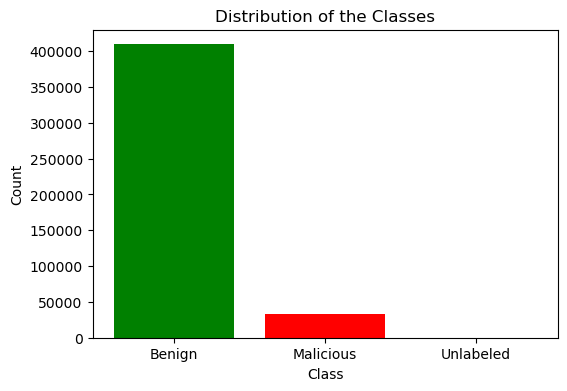

Training set semi labeled:
Label
Benign        409339
Malicious      32418
Unlabeled    5869948
Name: count, dtype: int32
Malicious/Benign: 7.92%



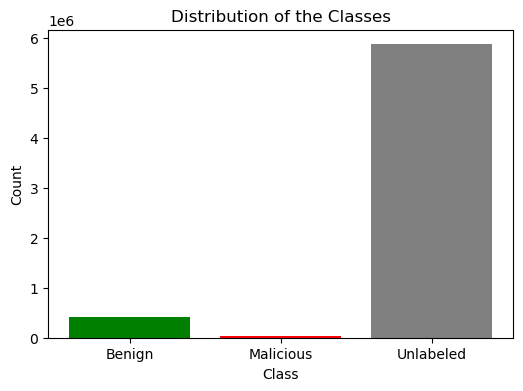

Test set:
Label
Benign       1462143
Malicious     115447
Unlabeled          0
Name: count, dtype: int32
Malicious/Benign: 7.90%



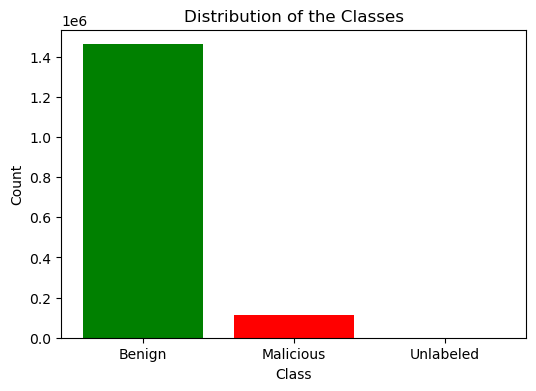

In [12]:
# Function to save data into a csv file
def saveData(dataset, path):
    dataset.to_csv(path, index = False, single_file = True)

# Function to delete a file
def deleteData(path):
    if(os.path.isfile(path)):
        os.remove(path)

# Function to split the dataset into 2 classes and then save them into different files
def divideDataset(dataset):
    benign = dataset[dataset["Label"] == 0]
    malicious = dataset[dataset["Label"] == 1]
    saveData(benign, "Dataset/benign_classes.csv")
    saveData(malicious, "Dataset/malicious_classes.csv")

# Function to create the dataset splits and save them
def createTrainAndTestSet(dataset_class1, dataset_class2):
    fractions = [0.8, 0.2]
    fractions2 = [0.93, 0.07]
    train_set1, test_set1 = dataset_class1.random_split(fractions, random_state = RANDOM_STATE)
    train_set2, test_set2 = dataset_class2.random_split(fractions, random_state = RANDOM_STATE)
    train_set1_unlabeled, train_set1_labeled = train_set1.random_split(fractions2, random_state = RANDOM_STATE)
    train_set2_unlabeled, train_set2_labeled = train_set2.random_split(fractions2, random_state = RANDOM_STATE)
    train_set1_unlabeled["Label"] = -1
    train_set2_unlabeled["Label"] = -1
    train_set_only_labeled = dd.concat([train_set1_labeled, train_set2_labeled]) 
    train_set_only_labeled_shuffled = train_set_only_labeled.sample(frac = 1, random_state = RANDOM_STATE)  #trick to shuffle in Dask
    train_set_semi_labeled = dd.concat([train_set1_labeled, train_set2_labeled, train_set1_unlabeled, train_set2_unlabeled])
    train_set_semi_labeled_shuffled = train_set_semi_labeled.sample(frac = 1, random_state = RANDOM_STATE)  #trick to shuffle in Dask
    saveData(train_set_only_labeled_shuffled, "Dataset/train_set_only_labeled.csv")
    saveData(train_set_semi_labeled_shuffled, "Dataset/train_set_semi_labeled.csv")
    saveData(dd.concat([test_set1, test_set2]), "Dataset/test_set.csv")

# Function to return the stratified splits
def stratifiedSplit(dataset, overwrite):
    if not (os.path.isfile("Dataset/train_set_only_labeled.csv") and os.path.isfile("Dataset/train_set_semi_labeled.csv") 
            and os.path.isfile("Dataset/test_set.csv")) or overwrite:
        if(overwrite):
            paths = ["Dataset/benign_classes.csv", "Dataset/malicious_classes.csv", "Dataset/train_set_only_labeled.csv",
                     "Dataset/train_set_semi_labeled.csv", "Dataset/test_set.csv"]
            for path in paths:
                deleteData(path)
        divideDataset(dataset)
        benign = dd.read_csv("Dataset/benign_classes.csv")
        malicious = dd.read_csv("Dataset/malicious_classes.csv")
        createTrainAndTestSet(benign, malicious)
    train_set_only_labeled = dd.read_csv("Dataset/train_set_only_labeled.csv", dtype = {"Label": "int32"})   
    train_set_semi_labeled = dd.read_csv("Dataset/train_set_semi_labeled.csv", dtype = {"Label": "int32"})   
    test_set = dd.read_csv("Dataset/test_set.csv", dtype = {"Label": "int32"}) 
    return train_set_only_labeled, train_set_semi_labeled, test_set
    
train_set_only_labeled, train_set_semi_labeled, test_set = stratifiedSplit(dataset, False)
datasets = [("Training set fully labeled", train_set_only_labeled), ("Training set semi labeled", train_set_semi_labeled), ("Test set", test_set)]
for name, dt in datasets:
    print(f"{name}:")
    showCounts(dt, "Label", ["Benign", "Malicious", "Unlabeled"], {0: "Benign", 1: "Malicious", -1: "Unlabeled"}, 6, 4, "Distribution of the Classes", "Class", "Count", ['green', 'red', 'grey'], True)

## Preparing data for the model
As I see, these datasets were split correctly.   
Now I prepare the data for machine learning algorithms.

### Balancing
As can be observed, both in the fully labeled training set and in the semi-labeled training set, there is a strong class imbalance, with a clear predominance of benign samples.

According to a statistical study conducted by Cloudflare, approximately 6.8% of Internet traffic is associated with malicious activities. In the dataset under analysis, malicious instances account for about 7.9% of the total samples, which is consistent with real-world conditions.

To address this imbalance, oversampling techniques could be applied by increasing the number of minority class examples (e.g., through duplication), but this may lead to overfitting. Alternatively, undersampling techniques can be used by reducing the number of majority class samples, at the cost of potentially losing some information.

In this work, however, no explicit resampling techniques are applied in order to preserve the original distribution of the data within the training set. Modifying the class distribution could alter the representativeness of the dataset with respect to real-world traffic conditions.

Instead, the imbalance is handled during the modeling phase by assigning a balanced class weight to the learning algorithm. This approach allows the model to give higher importance to the minority (malicious) class without modifying the underlying data distribution, thereby improving its ability to correctly identify underrepresented samples.

In [13]:
#Function to balance the dataset
def balancer(dataset, name):
    dataset_benign = dataset[dataset["Label"] == 0]
    dataset_malicious = dataset[dataset["Label"] != 0]
    fractionBalancer = 1/3  # This var decide how much to balance
    dataset_benign = dataset_benign.sample(frac = fractionBalancer, random_state = RANDOM_STATE)
    dataset = dd.concat([dataset_benign, dataset_malicious])
    dataset = dataset.sample(frac = 1, random_state = RANDOM_STATE) #shuffle
    print(name)
    showCounts(dataset, "Label", ["Benign", "Malicious"], {0: "Benign", 1: "Malicious"}, 6, 4, "Distribution of the Classes", "Class", "Count", ['green', 'red'], True)
    return dataset

#Balancer not applied    
#train_set_only_labeled = balancer(train_set_only_labeled, "Train_set_only_labeled")   
#train_set_semi_labeled = balancer(train_set_semi_labeled, "Train_set_semi_labeled")

### Separation of input features and target labels
In this step, the datasets are split into input features (x) and target variables (y) for the training set and test set. This separation is performed for both the fully labeled dataset and the semi labeled dataset, in order to properly prepare the data for model training and evaluation.

In [14]:
x_train_only_labeled = train_set_only_labeled.drop("Label", axis = 1)
y_train_only_labeled = train_set_only_labeled["Label"]

x_train_semi_labeled = train_set_semi_labeled.drop("Label", axis = 1)
y_train_semi_labeled = train_set_semi_labeled["Label"]

x_test = test_set.drop("Label", axis = 1)
y_test = test_set["Label"]

### Analyzing correlation
Correlation analysis was performed on the fully labeled subset, and the same feature relationships were assumed to hold for the semi-supervised dataset, which extends the original distribution with unlabeled samples.

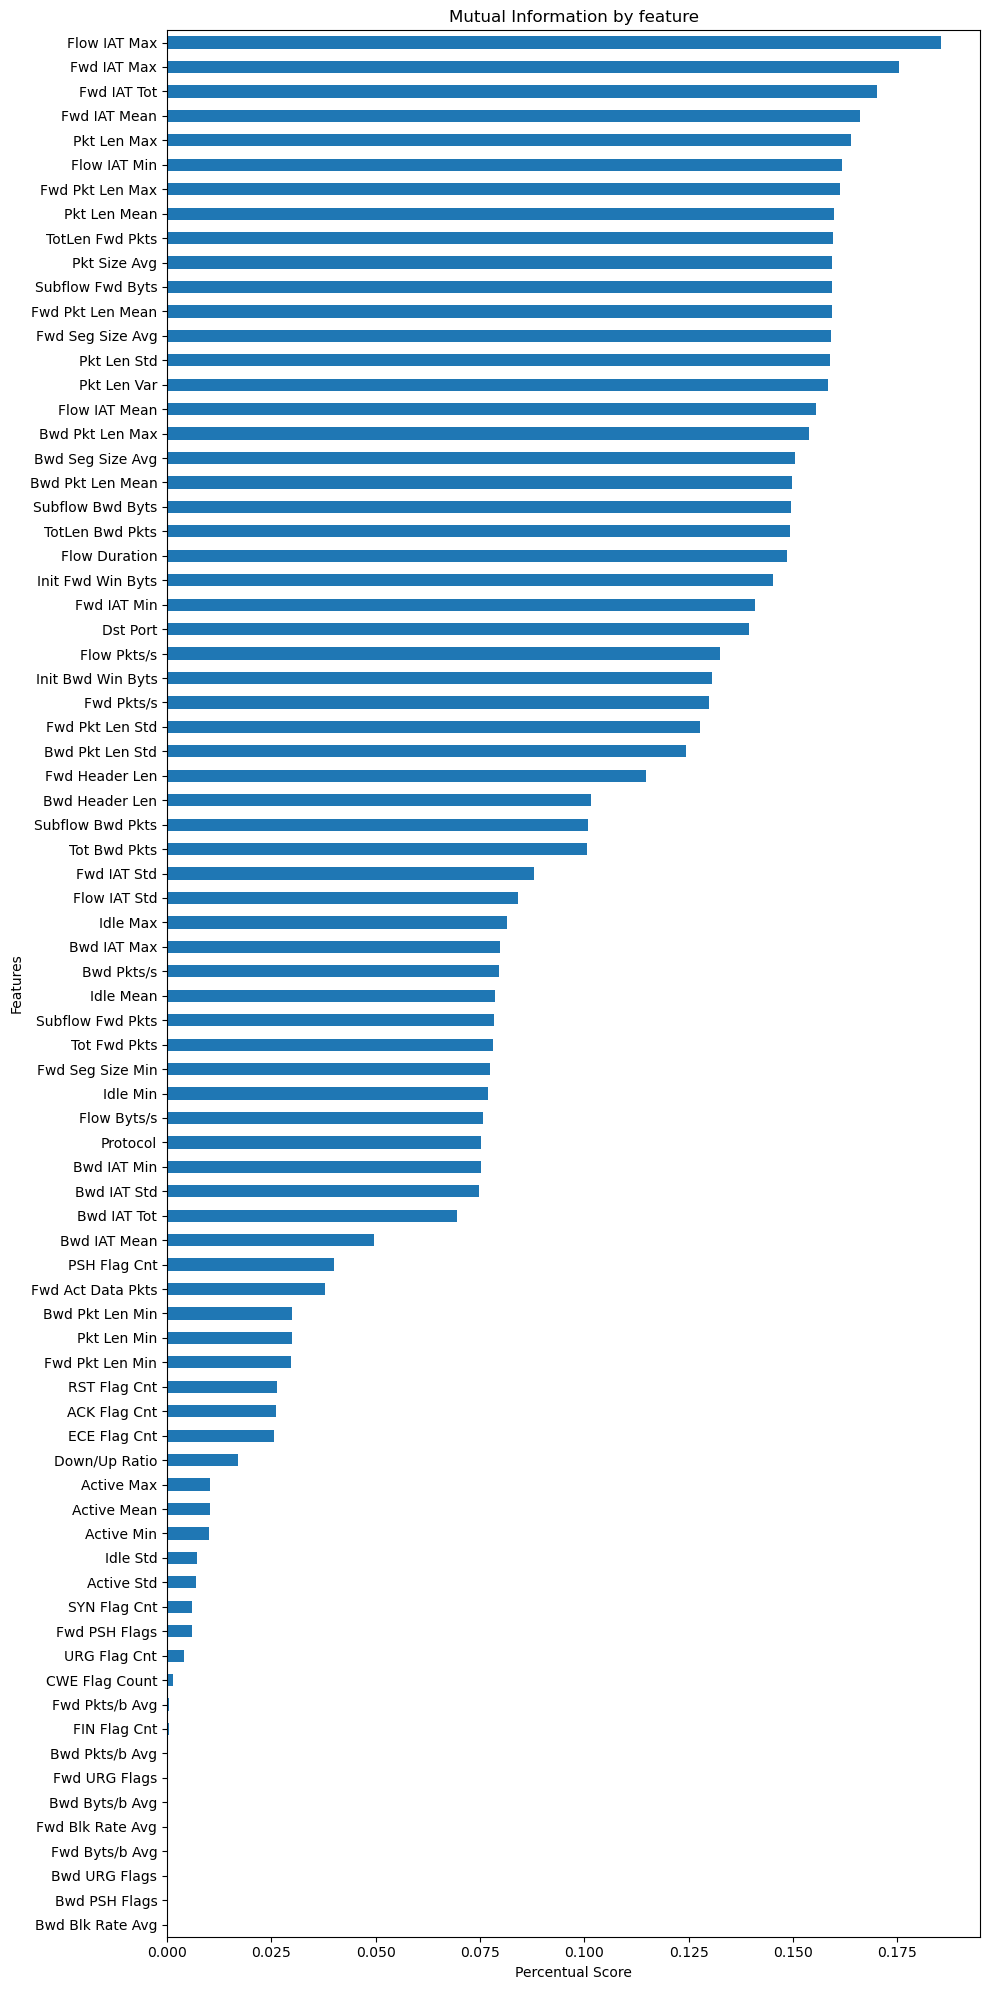

In [15]:
# Function to show feature-target correlation
def showFeatureTargetCorrelation(mutualInfoClassifier_series):
    plt.figure(figsize = (10, 20))
    mutualInfoClassifier_series.sort_values().plot(kind = "barh")
    plt.title("Mutual Information by feature")
    plt.xlabel("Percentual Score")
    plt.ylabel("Features")
    plt.tight_layout()
    plt.show()

# Function to compute mutual correlation, show and return the results
def startAnalysisCorrelation(x, y):
    mutualInfoClassifier = mutual_info_classif(x, y)
    mutualInfoClassifier_series = pd.Series(mutualInfoClassifier, index = x.columns).sort_values(ascending = False)
    showFeatureTargetCorrelation(mutualInfoClassifier_series)
    return mutualInfoClassifier_series

# Function to remove features with less than 5% correlation with the target   
def removeLowCorrelationFeatures(x, mutualInfoClassifier_series):
    return x.drop(mutualInfoClassifier_series[mutualInfoClassifier_series < 0.05].index, axis = 1)
    
result = startAnalysisCorrelation(x_train_only_labeled, y_train_only_labeled)

Now I remove all features that have less than 5% correlation with the target.

In [16]:
x_train_only_labeled = removeLowCorrelationFeatures(x_train_only_labeled, result)
x_train_semi_labeled = removeLowCorrelationFeatures(x_train_semi_labeled, result)
x_test = removeLowCorrelationFeatures(x_test, result)

print(f"Number of features: {x_train_only_labeled.shape[1]}\n{x_train_only_labeled.columns}")

Number of features: 49
Index(['Dst Port', 'Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts',
       'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max',
       'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
       'Bwd Pkts/s', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std',
       'Pkt Len Var', 'Pkt Size Avg', 'Fwd Seg Size Avg', 'Bwd Seg Size Avg',
       'Subflow Fwd Pkts', 'Subflow Fwd Byts', 'Subflow Bwd Pkts',
       'Subflow Bwd Byts', 'Init Fwd Win Byts', 'Init Bwd Win Byts',
       'Fwd Seg Size Min', 'Idle Mean', 'Idle Max', 'Idle Min'],
      dtype='object')


Now I scale all features using StandardScaler for train and test splits

In [17]:
scaler1 = StandardScaler()
x_train_only_labeled = scaler1.fit_transform(x_train_only_labeled)
x_test_only_labeled = scaler1.transform(x_test)

scaler2 = StandardScaler()
x_train_semi_labeled = scaler2.fit_transform(x_train_semi_labeled)
x_test_semi_labeled = scaler2.transform(x_test)

## Semi-Supervised learning approaches
Within the context of semi-supervised learning, several approaches have been proposed to effectively exploit unlabeled data alongside a limited set of labeled examples. One widely used technique is self-training, a wrapper-based method in which a model is initially trained on labeled data and then iteratively assigns pseudo-labels to unlabeled instances based on high-confidence predictions. These newly labeled samples are subsequently incorporated into the training set, allowing the model to progressively refine its performance.

In addition, graph-based methods such as Label Propagation and Label Spreading provide an alternative perspective. In these approaches, data points are represented as nodes within a graph, where edges encode similarities between instances. Label Propagation directly spreads label information across the graph structure, whereas Label Spreading introduces a regularization mechanism that improves robustness, particularly in the presence of noisy data. 

In the user guide is written : "LabelPropagation uses the raw similarity matrix constructed from the data with no modifications. In contrast, LabelSpreading minimizes a loss function that has regularization properties, as such it is often more robust to noise. The algorithm iterates on a modified version of the original graph and normalizes the edge weights by computing the normalized graph Laplacian matrix. This procedure is also used in Spectral clustering"

Overall, these methods aim to leverage the underlying structure of the data distribution in order to enhance classification performance, especially in scenarios where labeled data is scarce. 
## Choice of the model and the SSL approaches
As the classification model, I use logistic regression, a simple and effective approach for binary classification tasks.

For completeness, the project also presents a comparison between a model trained using only 7% of the labeled data and models that additionally exploit the remaining 93% of unlabeled data. In particular, the latter are trained using three semi-supervised approaches: self-training, label propagation and label spreading.

From this point onward, the model training will be carried out using scikit-learn, as the processed datasets are of a reasonable size to be handled in memory (RAM). The work performed so far has been useful to simulate a more realistic scenario, where datasets are significantly larger and cannot be fully preprocessed or engineered in memory.

### Define the model and training
Now, the Logistic Regression model is instantiated and its performance is analyzed using grid search combined with cross-validation, as implemented in scikit-learn. This approach allows the evaluation of multiple hyperparameter configurations in a systematic way, providing a more reliable estimate of the model’s generalization performance compared to a single validation split.

In [18]:
logisticParams = {"C": [0.01, 0.1, 1, 10],"solver": ["lbfgs", "liblinear"]}

# Function to show confusion matrix
def showConfusionMatrix(y_val, y_pred):
    matrix = confusion_matrix(y_val, y_pred)   
    disp = ConfusionMatrixDisplay(confusion_matrix = matrix)
    disp.plot()
    plt.show()

# Function to show results of grid search
def plot_train_vs_test(results):
    plt.figure()
    plt.plot(results["mean_train_score"], label = "Train score")
    plt.plot(results["mean_test_score"], label = "CV score")
    plt.legend()
    plt.title("Train vs Validation score (GridSearch)")
    plt.xlabel("Configuration index")
    plt.ylabel("F1 macro")
    plt.show()

# Function that uses grid search to search best params to avoid overfitting
def searchBestModel(params, model, cv, xTrain, yTrain):
    grid = GridSearchCV(model, params, cv = cv, scoring = "f1_macro", return_train_score = True, n_jobs = -1)
    grid.fit(xTrain, yTrain)
    results = pd.DataFrame(grid.cv_results_)
    results["overfit_gap"] = results["mean_train_score"] - results["mean_test_score"]
    print(results[["params", "mean_train_score", "mean_test_score"]].to_string(), "\n\n", results[["overfit_gap"]], "\n")
    plot_train_vs_test(results)

warnings.filterwarnings("ignore", category = ConvergenceWarning)
warnings.filterwarnings("ignore", category = RuntimeWarning)

#### Supervised learning
I apply supervised learning by selecting **logistic regression** as the chosen model.

                               params  mean_train_score  mean_test_score
0      {'C': 0.01, 'solver': 'lbfgs'}          0.898762         0.890966
1  {'C': 0.01, 'solver': 'liblinear'}          0.894048         0.884784
2       {'C': 0.1, 'solver': 'lbfgs'}          0.953370         0.944006
3   {'C': 0.1, 'solver': 'liblinear'}          0.950245         0.942031
4         {'C': 1, 'solver': 'lbfgs'}          0.971778         0.963039
5     {'C': 1, 'solver': 'liblinear'}          0.970971         0.962603
6        {'C': 10, 'solver': 'lbfgs'}          0.979762         0.977986
7    {'C': 10, 'solver': 'liblinear'}          0.978958         0.977123 

    overfit_gap
0     0.007795
1     0.009264
2     0.009364
3     0.008214
4     0.008739
5     0.008368
6     0.001775
7     0.001835 



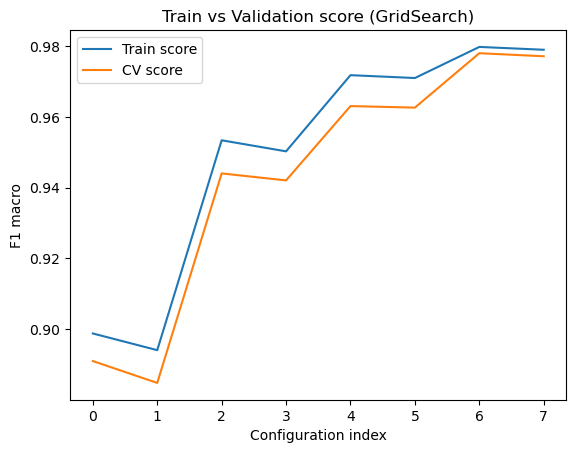

In [19]:
model = LogisticRegression(class_weight = "balanced", max_iter = 1000)
searchBestModel(logisticParams, model, 5, x_train_only_labeled.compute(), y_train_only_labeled.compute())

The parameters at index 6 provide the best trade-off between performance and stability, offering a good balance between predictive accuracy and low overfitting.

In [20]:
model = LogisticRegression(C = 10, solver = "lbfgs", class_weight = "balanced", max_iter = 1000)
model.fit(x_train_only_labeled, y_train_only_labeled)

LogisticRegression(C=10, class_weight='balanced', max_iter=1000)

### Self Training  
Self-training is a semi-supervised learning approach where a model trained on labeled data is used to generate pseudo-labels for unlabeled data. Only the most confident predictions are added to the training set, and the model is retrained iteratively. This allows the model to leverage large amounts of unlabeled data, but it may propagate errors if incorrect predictions are included.  

I am unable to perform fine-tuning for self-training using the full dataset because my computer does not have enough RAM and runs out of memory during training. As a result, it cannot generate the graph and statistics needed to choose the optimal threshold. Therefore, to stay consistent with the concept of self-training, I select a very high threshold of 0.9, which helps minimize error propagation.

In [21]:
model2 = LogisticRegression(C = 10, solver = "lbfgs", class_weight = "balanced", max_iter = 1000)
selfTrainingModel = SelfTrainingClassifier(model2, threshold = 0.9, max_iter = 20)
selfTrainingModel.fit(x_train_semi_labeled, y_train_semi_labeled)

SelfTrainingClassifier(base_estimator=LogisticRegression(C=10,
                                                         class_weight='balanced',
                                                         max_iter=1000),
                       max_iter=20, threshold=0.9)

### Evaluating the models
I am evaluating and comparing the performance differences between the two models on the test set to assess which one generalizes better to unseen data.

              precision    recall  f1-score   support

           0   0.999999  0.994120  0.997051   1462143
           1   0.930693  0.999991  0.964099    115447

    accuracy                       0.994550   1577590
   macro avg   0.965346  0.997056  0.980575   1577590
weighted avg   0.994928  0.994550  0.994640   1577590



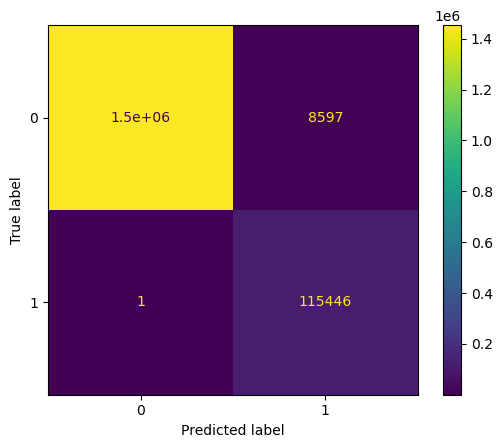

In [22]:
only_labeled_predictions = model.predict(x_test_only_labeled)
report = classification_report(y_test, only_labeled_predictions, digits = 6)
print(report)
showConfusionMatrix(y_test, only_labeled_predictions)

As can be observed, although the labeled portion of the training set represents only about 7% of the original dataset, it still contains a very large number of examples; despite being highly imbalanced, assigning greater weight to the “1” (Malicious) class allows the logistic regression model to achieve very high overall performance. However, it also tends to classify some benign instances as malicious, leading to a slight deterioration in precision while maintaining an extremely high recall.

              precision    recall  f1-score   support

           0   0.999999  0.992873  0.996423   1462143
           1   0.917206  0.999991  0.956811    115447

    accuracy                       0.993394   1577590
   macro avg   0.958603  0.996432  0.976617   1577590
weighted avg   0.993941  0.993394  0.993525   1577590



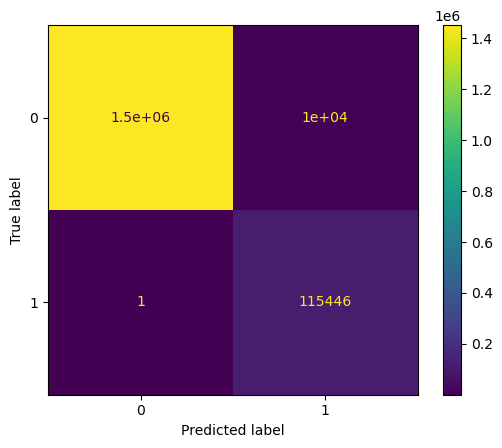

In [23]:
semi_labeled_predictions = selfTrainingModel.predict(x_test_semi_labeled)
report = classification_report(y_test, semi_labeled_predictions, digits = 6)
print(report)
showConfusionMatrix(y_test, semi_labeled_predictions)

Despite the availability of a very large dataset and the use of a simple logistic regression model with class weight balancing (giving more importance to the minority class “Malicious”), the application of the self-training approach in scikit-learn does not lead to an improvement in performance. On the contrary, a slight overall degradation is observed.

An analysis of the confusion matrix highlights a clear tendency of the model to classify more instances as “Malicious” than appropriate, resulting in an increase in false positives. This behavior indicates that, although the model maintains a strong ability to detect malicious cases, it does so at the expense of precision.

Even when adopting a high confidence threshold (e.g., 0.9), the pseudo-labeling process still introduces errors: some incorrect predictions, despite being considered “confident,” are included in the training set, leading to the propagation and reinforcement of incorrect patterns. As a result, instead of improving, the model’s performance slightly deteriorates.

<span style="color:orange; font-weight:bold;">Warning:</span> Label Propagation and Label Spreading algorithms would require an enormous amount of RAM and, even if sufficient memory were available, a significant amount of computation time to be effectively used. Therefore, in order to demonstrate their effectiveness and more generally to simulate a realistic scenario in which the available data is much smaller than the current dataset, we can repeat our analysis by reducing each portion of the dataset to only 0.001% of the instances currently available.

### SSL scenario with limited amount of data

#### Dataset downsampling
First, I take the training set and test set and apply a reduction to 0.001% of their original size using the same function defined before to mantain the proportion.

Training set fully labeled:
Label
Benign       407
Malicious     31
Unlabeled      0
Name: count, dtype: int32
Malicious/Benign: 7.62%



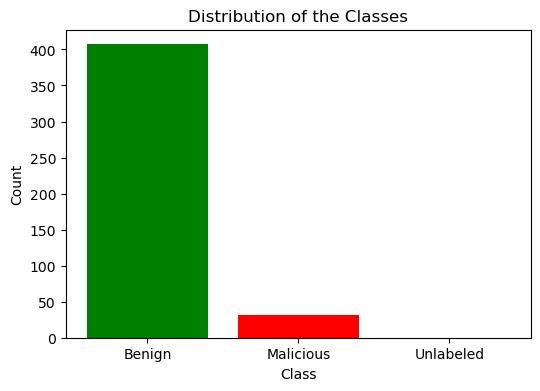

Training set semi labeled:
Label
Benign        407
Malicious      31
Unlabeled    5858
Name: count, dtype: int32
Malicious/Benign: 7.62%



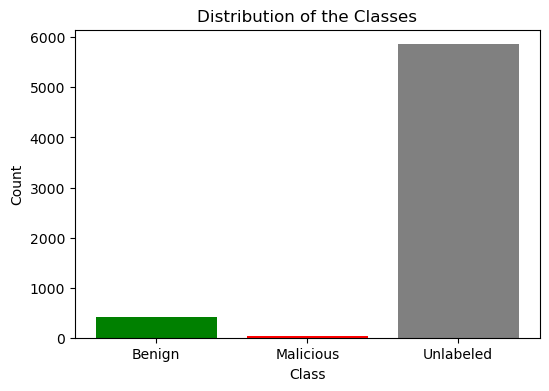

Test set:
Label
Benign       1489
Malicious     105
Unlabeled       0
Name: count, dtype: int32
Malicious/Benign: 7.05%



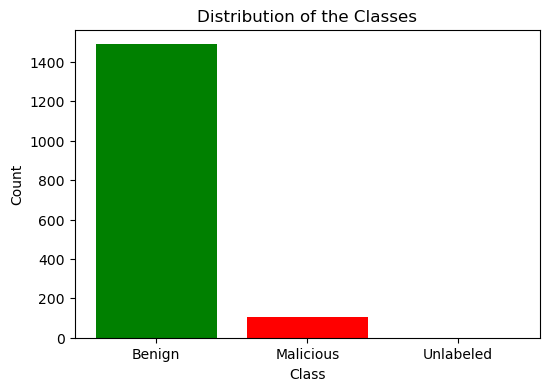

In [24]:
train_set_only_labeled, train_set_semi_labeled, test_set = stratifiedSplit(dataset.sample(frac = 0.001, random_state = RANDOM_STATE), True)
datasets = [("Training set fully labeled", train_set_only_labeled), ("Training set semi labeled", train_set_semi_labeled), ("Test set", test_set)]
for name, dt in datasets:
    print(f"{name}:")
    showCounts(dt, "Label", ["Benign", "Malicious", "Unlabeled"], {0: "Benign", 1: "Malicious", -1: "Unlabeled"}, 6, 4, "Distribution of the Classes", "Class", "Count", ['green', 'red', 'grey'], True)

#### Reapplying previous data preparation steps  
Now I reapply the separation of features from the labels.

In [25]:
x_train_only_labeled = train_set_only_labeled.drop("Label", axis = 1)
y_train_only_labeled = train_set_only_labeled["Label"]

x_train_semi_labeled = train_set_semi_labeled.drop("Label", axis = 1)
y_train_semi_labeled = train_set_semi_labeled["Label"]

x_test = test_set.drop("Label", axis = 1)
y_test = test_set["Label"]

I do correlation analysis

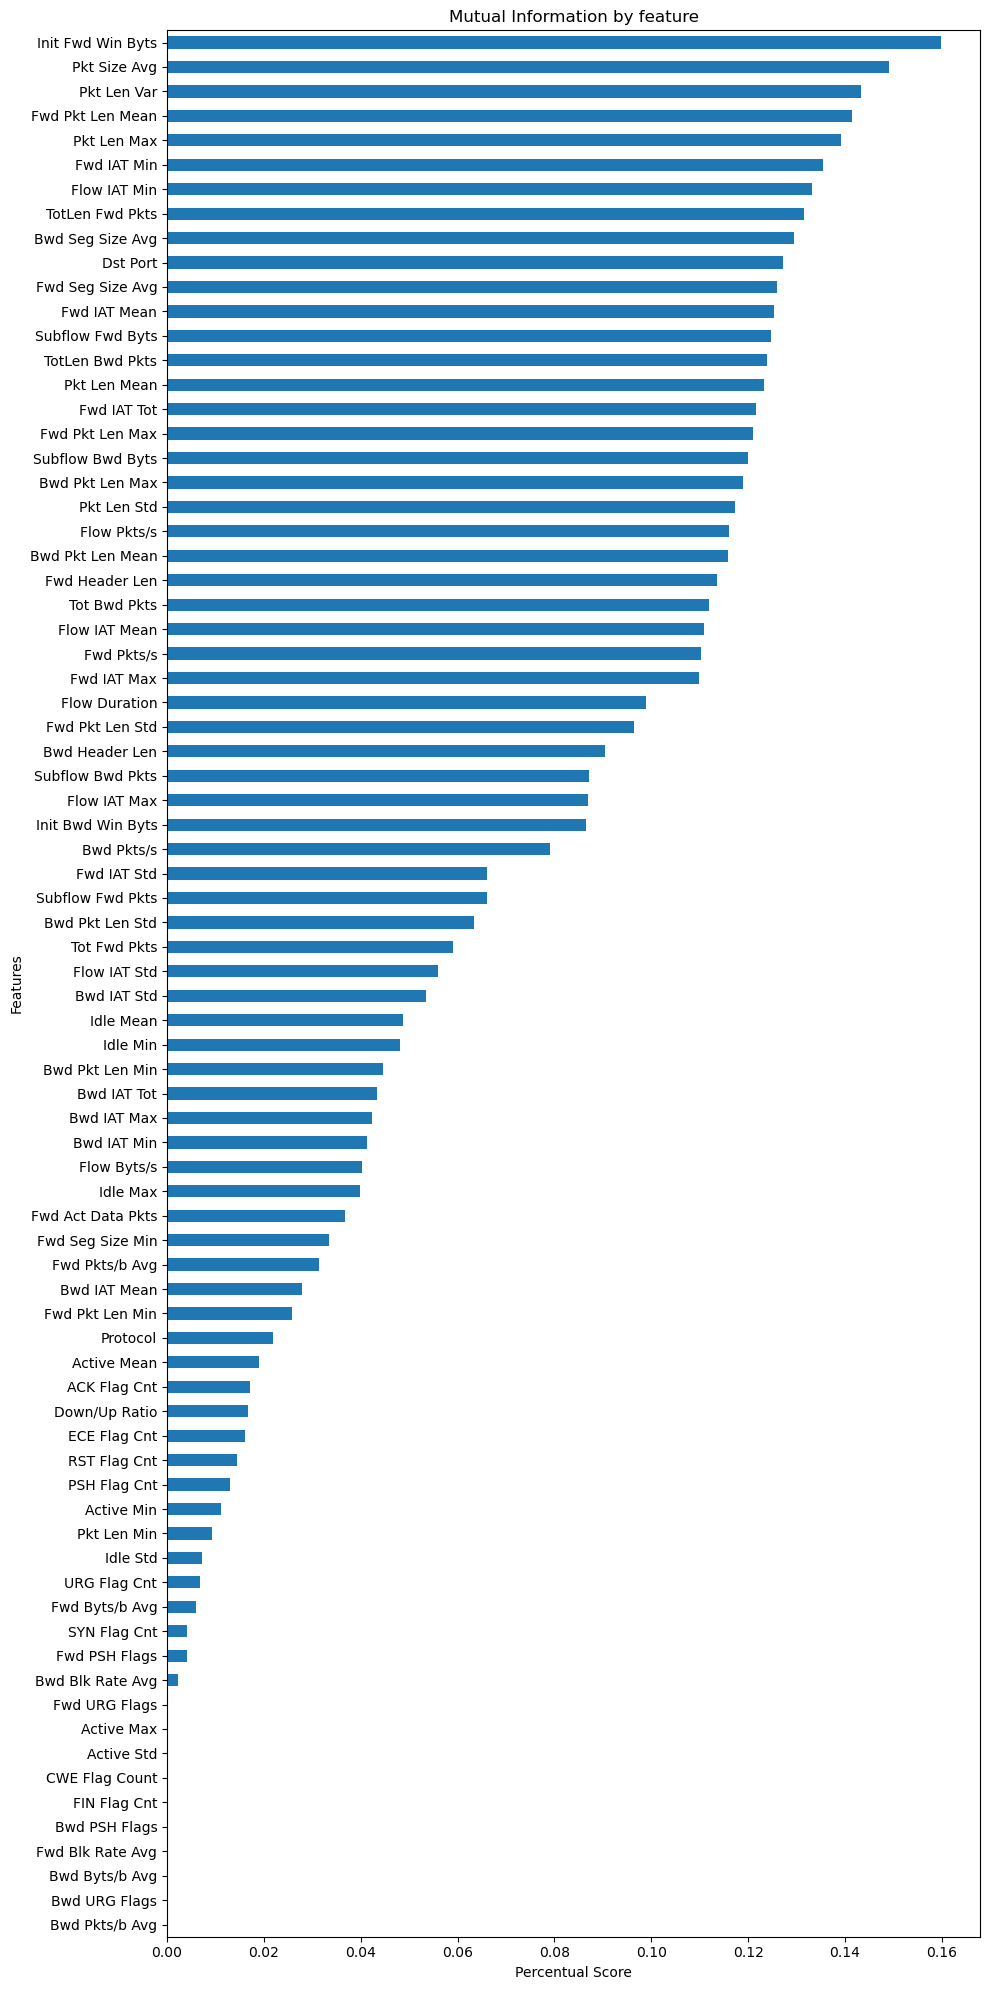

Number of features: 40
Index(['Dst Port', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts',
       'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max',
       'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Std', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
       'Bwd Pkts/s', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std',
       'Pkt Len Var', 'Pkt Size Avg', 'Fwd Seg Size Avg', 'Bwd Seg Size Avg',
       'Subflow Fwd Pkts', 'Subflow Fwd Byts', 'Subflow Bwd Pkts',
       'Subflow Bwd Byts', 'Init Fwd Win Byts', 'Init Bwd Win Byts'],
      dtype='object')


In [26]:
result = startAnalysisCorrelation(x_train_only_labeled, y_train_only_labeled)

x_train_only_labeled = removeLowCorrelationFeatures(x_train_only_labeled, result)
x_train_semi_labeled = removeLowCorrelationFeatures(x_train_semi_labeled, result)
x_test = removeLowCorrelationFeatures(x_test, result)

print(f"Number of features: {x_train_only_labeled.shape[1]}\n{x_train_only_labeled.columns}")

I do feature scaling

In [27]:
x_train_only_labeled = scaler1.fit_transform(x_train_only_labeled)
x_test_only_labeled = scaler1.transform(x_test)

x_train_semi_labeled = scaler2.fit_transform(x_train_semi_labeled)
x_test_semi_labeled = scaler2.transform(x_test)

#### Supervised learning
Now I proceed to reapply the supervised training of the previously selected model using a significantly smaller available dataset.

For each model, the non-tuned instance is also used at the end to evaluate and compare the possible performance scenarios.

                               params  mean_train_score  mean_test_score
0      {'C': 0.01, 'solver': 'lbfgs'}          0.773979         0.769646
1  {'C': 0.01, 'solver': 'liblinear'}          0.657355         0.660136
2       {'C': 0.1, 'solver': 'lbfgs'}          0.776406         0.781310
3   {'C': 0.1, 'solver': 'liblinear'}          0.758973         0.761426
4         {'C': 1, 'solver': 'lbfgs'}          0.816600         0.806396
5     {'C': 1, 'solver': 'liblinear'}          0.794306         0.788484
6        {'C': 10, 'solver': 'lbfgs'}          0.855407         0.859359
7    {'C': 10, 'solver': 'liblinear'}          0.850370         0.853714 

    overfit_gap
0     0.004333
1    -0.002781
2    -0.004904
3    -0.002452
4     0.010204
5     0.005821
6    -0.003952
7    -0.003344 



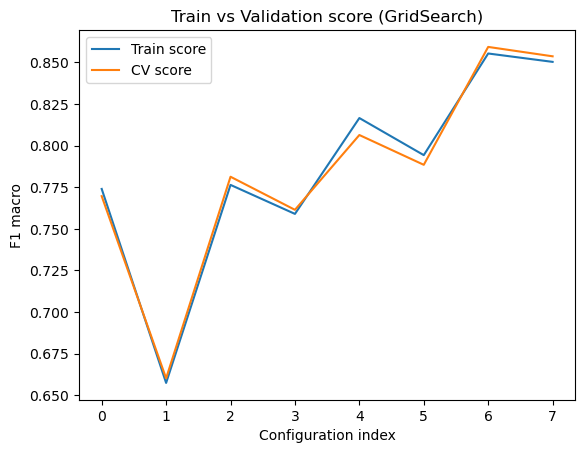

In [28]:
model_not_tuned = LogisticRegression(class_weight = "balanced", max_iter = 1000)
model_not_tuned.fit(x_train_only_labeled, y_train_only_labeled)
model = LogisticRegression(class_weight = "balanced", max_iter = 1000)
searchBestModel(logisticParams, model, 5, x_train_only_labeled.compute(), y_train_only_labeled.compute())

The parameters at index 7 provide the best trade-off between performance and stability, offering a good balance between predictive accuracy and low overfitting.  


In [29]:
model = LogisticRegression(C = 10, solver = "liblinear", class_weight = "balanced", max_iter = 1000)
model.fit(x_train_only_labeled, y_train_only_labeled)

LogisticRegression(C=10, class_weight='balanced', max_iter=1000,
                   solver='liblinear')

#### SSL self training
Now I proceed to reapply the semi-supervised self-training of the previously selected model using a significantly smaller available dataset.  

First I choose a very high threshold, because I want to avoid the model propagating errors during pseudo-labeling. In self-training, low-confidence predictions can easily introduce noise, which then gets amplified in subsequent iterations. So I intentionally avoid testing configurations with lower thresholds, since they would allow more uncertain pseudo-labels to be added to the training set. This choice is also motivated by the fact that my dataset is strongly imbalanced. In such cases, a lower threshold can disproportionately affect minority classes, leading to biased or unstable pseudo-label propagation. A higher threshold ensures that only highly confident predictions are used, improving the reliability of the self-training process even if it reduces the number of newly added samples.

In [30]:
model2 = LogisticRegression(C = 10, solver = "liblinear", class_weight = "balanced", max_iter = 1000)
model2_not_tuned = LogisticRegression(class_weight = "balanced", max_iter = 1000)
selfTrainingModel_not_tuned = SelfTrainingClassifier(model2_not_tuned, threshold = 0.9, max_iter = 20)
selfTrainingModel_not_tuned.fit(x_train_semi_labeled, y_train_semi_labeled)
selfTrainingModel = SelfTrainingClassifier(model2, threshold = 0.9, max_iter = 20)
selfTrainingModel.fit(x_train_semi_labeled, y_train_semi_labeled)

SelfTrainingClassifier(base_estimator=LogisticRegression(C=10,
                                                         class_weight='balanced',
                                                         max_iter=1000,
                                                         solver='liblinear'),
                       max_iter=20, threshold=0.9)

#### Label propagation  
Label Propagation is a semi-supervised learning algorithm used on graphs where only a small portion of the data is labeled and the rest is unlabeled. The main idea is that similar or connected nodes are likely to share the same label. The algorithm represents data as a graph where nodes are data points and edges represent similarity. Initially, labeled nodes keep their labels while unlabeled nodes have none. Then, in an iterative process, each node updates its label by looking at the labels of its neighbors, usually choosing the most frequent or strongly weighted label among them. This process repeats until the labels stop changing and the system converges. In the end, labels propagate through the graph from labeled nodes to unlabeled ones. Label Propagation is useful when labeled data is limited but relationships between data points are known, such as in social networks, text classification, or clustering tasks.

In [31]:
labelPropagation_not_tuned = LabelPropagation()
labelPropagation_not_tuned.fit(x_train_semi_labeled, y_train_semi_labeled)
y_propagated = labelPropagation_not_tuned.transduction_
modelPropagated_not_tuned = LogisticRegression(class_weight = "balanced", max_iter = 1000)
modelPropagated_not_tuned.fit(x_train_semi_labeled, y_propagated)

LogisticRegression(class_weight='balanced', max_iter=1000)

kernel:  rbf
                               params  mean_train_score  mean_test_score
0      {'C': 0.01, 'solver': 'lbfgs'}          0.780898         0.767929
1  {'C': 0.01, 'solver': 'liblinear'}          0.750608         0.738406
2       {'C': 0.1, 'solver': 'lbfgs'}          0.795600         0.780574
3   {'C': 0.1, 'solver': 'liblinear'}          0.791386         0.777237
4         {'C': 1, 'solver': 'lbfgs'}          0.842858         0.828067
5     {'C': 1, 'solver': 'liblinear'}          0.838946         0.822834
6        {'C': 10, 'solver': 'lbfgs'}          0.884647         0.869771
7    {'C': 10, 'solver': 'liblinear'}          0.883097         0.865872 

    overfit_gap
0     0.012970
1     0.012201
2     0.015026
3     0.014149
4     0.014791
5     0.016113
6     0.014876
7     0.017225 



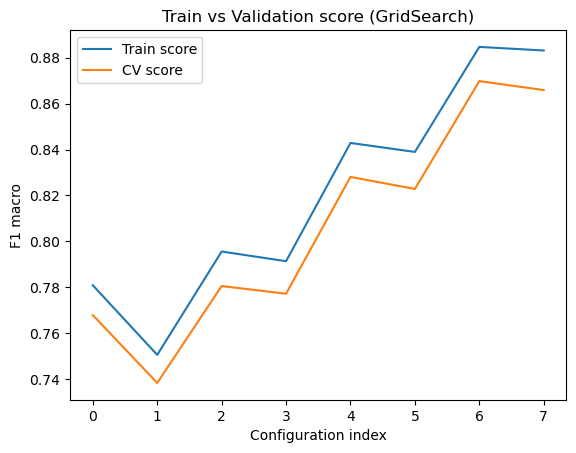

kernel:  knn
                               params  mean_train_score  mean_test_score
0      {'C': 0.01, 'solver': 'lbfgs'}          0.775419         0.772862
1  {'C': 0.01, 'solver': 'liblinear'}          0.738695         0.739326
2       {'C': 0.1, 'solver': 'lbfgs'}          0.812764         0.811293
3   {'C': 0.1, 'solver': 'liblinear'}          0.785078         0.784865
4         {'C': 1, 'solver': 'lbfgs'}          0.833714         0.835443
5     {'C': 1, 'solver': 'liblinear'}          0.829751         0.830341
6        {'C': 10, 'solver': 'lbfgs'}          0.876698         0.878097
7    {'C': 10, 'solver': 'liblinear'}          0.875120         0.876966 

    overfit_gap
0     0.002558
1    -0.000631
2     0.001471
3     0.000213
4    -0.001730
5    -0.000590
6    -0.001399
7    -0.001846 



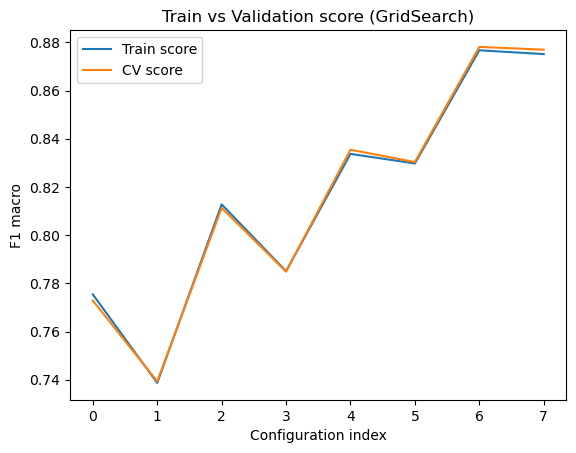

In [32]:
kernels = ["rbf", "knn"]

for k in kernels:
    labelPropagation = LabelPropagation(kernel = k)
    labelPropagation.fit(x_train_semi_labeled, y_train_semi_labeled)
    y_propagated = labelPropagation.transduction_
    modelPropagated = LogisticRegression(class_weight = "balanced", max_iter = 1000)
    print("kernel: ", k)
    searchBestModel(logisticParams, modelPropagated, 5, x_train_semi_labeled.compute(), y_propagated)

When fine-tuning the logistic regression model after applying label propagation with both kernels (keeping other
  parameters at default), the combination of KNN kernel for label propagation and logistic regression parameters at
  index 7 yields the best trade-off between performance and overfitting.

In [33]:
labelPropagation = LabelPropagation(kernel = "knn")
labelPropagation.fit(x_train_semi_labeled, y_train_semi_labeled)
y_propagated = labelPropagation.transduction_
modelPropagated = LogisticRegression(C = 10, solver = "liblinear", class_weight = "balanced", max_iter = 1000)
modelPropagated.fit(x_train_semi_labeled, y_propagated)

LogisticRegression(C=10, class_weight='balanced', max_iter=1000,
                   solver='liblinear')

#### Label spreading  
Label Spreading is a semi-supervised learning algorithm used on graphs where only a small portion of the data is labeled and the rest is unlabeled. The main idea is that similar or connected data points tend to share the same label, and labels are propagated through the graph based on these similarities.
Unlike Label Propagation, Label Spreading introduces a smoothing effect, meaning that even initially labeled points can slightly adjust their labels during the process. This makes the algorithm more robust to noise and reduces the risk of spreading incorrect labels. The method balances two objectives: staying close to the initial labels and ensuring smoothness across the graph structure.
In practice, Label Spreading iteratively updates labels based on neighboring nodes until convergence. It is particularly useful when labeled data is limited and potentially noisy, such as in social networks, text classification, or clustering tasks.

In [34]:
labelSpreading_not_tuned = LabelSpreading()
labelSpreading_not_tuned.fit(x_train_semi_labeled, y_train_semi_labeled)
y_propagated = labelSpreading_not_tuned.transduction_
modelSpreaded_not_tuned = LogisticRegression(class_weight = "balanced", max_iter = 1000)
modelSpreaded_not_tuned.fit(x_train_semi_labeled, y_propagated)

LogisticRegression(class_weight='balanced', max_iter=1000)

kernel:  rbf
                               params  mean_train_score  mean_test_score
0      {'C': 0.01, 'solver': 'lbfgs'}          0.791783         0.776248
1  {'C': 0.01, 'solver': 'liblinear'}          0.752011         0.742913
2       {'C': 0.1, 'solver': 'lbfgs'}          0.809112         0.791569
3   {'C': 0.1, 'solver': 'liblinear'}          0.801336         0.785565
4         {'C': 1, 'solver': 'lbfgs'}          0.846405         0.830943
5     {'C': 1, 'solver': 'liblinear'}          0.844451         0.827680
6        {'C': 10, 'solver': 'lbfgs'}          0.889322         0.870995
7    {'C': 10, 'solver': 'liblinear'}          0.887063         0.867438 

    overfit_gap
0     0.015535
1     0.009098
2     0.017542
3     0.015771
4     0.015463
5     0.016771
6     0.018327
7     0.019625 



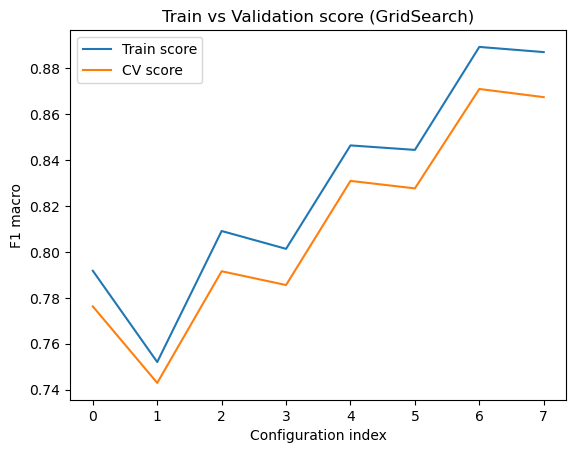

kernel:  knn
                               params  mean_train_score  mean_test_score
0      {'C': 0.01, 'solver': 'lbfgs'}          0.747363         0.748935
1  {'C': 0.01, 'solver': 'liblinear'}          0.714678         0.716074
2       {'C': 0.1, 'solver': 'lbfgs'}          0.789229         0.791311
3   {'C': 0.1, 'solver': 'liblinear'}          0.754859         0.755091
4         {'C': 1, 'solver': 'lbfgs'}          0.796519         0.799781
5     {'C': 1, 'solver': 'liblinear'}          0.794386         0.797193
6        {'C': 10, 'solver': 'lbfgs'}          0.836449         0.840199
7    {'C': 10, 'solver': 'liblinear'}          0.834423         0.837671 

    overfit_gap
0    -0.001572
1    -0.001395
2    -0.002081
3    -0.000232
4    -0.003262
5    -0.002807
6    -0.003750
7    -0.003248 



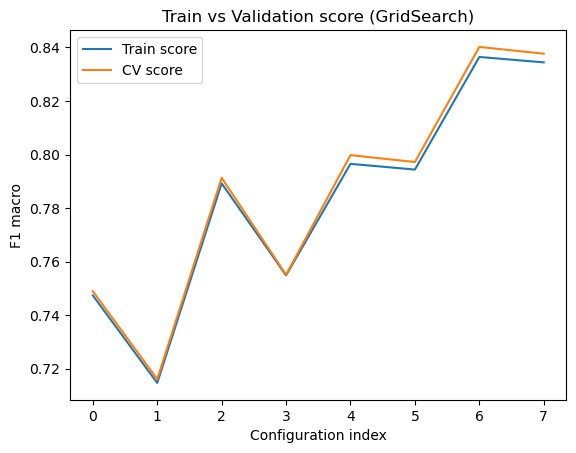

In [35]:
for k in kernels:
    labelSpreading = LabelSpreading(kernel = k)
    labelSpreading.fit(x_train_semi_labeled, y_train_semi_labeled)
    y_propagated = labelSpreading.transduction_
    modelSpreaded = LogisticRegression(class_weight = "balanced", max_iter = 1000)
    print("kernel: ", k)
    searchBestModel(logisticParams, modelSpreaded, 5, x_train_semi_labeled.compute(), y_propagated)

When fine-tuning the logistic regression model after applying label spreading with both kernels (keeping other parameters at default), the combination of rbf kernel for label spreading and logistic regression parameters at index 7 yields the best trade-off between performance and overfitting. (in this run, 6 would probably have been a better choice, but everything was executed using 7)

In [36]:
labelSpreading = LabelSpreading(kernel = "rbf")
labelSpreading.fit(x_train_semi_labeled, y_train_semi_labeled)
y_propagated = labelSpreading.transduction_
modelSpreaded = LogisticRegression(C = 10, solver = "liblinear", class_weight = "balanced", max_iter = 1000)
modelSpreaded.fit(x_train_semi_labeled, y_propagated)

LogisticRegression(C=10, class_weight='balanced', max_iter=1000,
                   solver='liblinear')

#### Evaluating the tuned models
I am evaluating and comparing the performance differences between the four tuned models on the test set to assess which one generalizes better to unseen data.

              precision    recall  f1-score   support

           0   1.000000  0.924110  0.960558      1489
           1   0.481651  1.000000  0.650155       105

    accuracy                       0.929109      1594
   macro avg   0.740826  0.962055  0.805357      1594
weighted avg   0.965855  0.929109  0.940112      1594



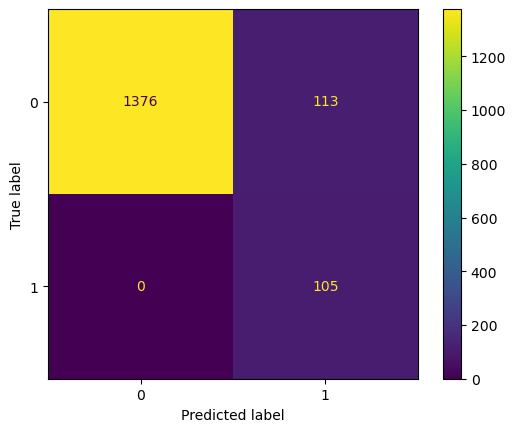

In [37]:
only_labeled_predictions = model.predict(x_test_only_labeled)
report_sl = classification_report(y_test, only_labeled_predictions, digits = 6)
report_sl_dict = classification_report(y_test, only_labeled_predictions, digits = 6, output_dict = True)
print(report_sl)
showConfusionMatrix(y_test, only_labeled_predictions)

The model achieves perfect recall (100%) for the "Malicious" class (class 1), but at the cost of low precision (48.1%) due to excessive false positives, where benign instances (class 0)
  are misclassified as "Malicious". The model prioritizes avoiding false
  negatives (critical in threat detection) by over-predicting malignancy.

  However, the high overall accuracy (92.9%) is largely misleading: it stems from the model's strong performance on the
  abundant benign class (93.4% of data), where precision is perfect (1.000) and recall is high (92.4%). In such extreme
  imbalance, accuracy inflates perceived performance, while the macro-averaged F1-score (0.805) better reflects the
  minority class's weaker F1 (0.741 vs. 0.962 for benign).

              precision    recall  f1-score   support

           0   1.000000  0.917394  0.956918      1489
           1   0.460526  1.000000  0.630631       105

    accuracy                       0.922836      1594
   macro avg   0.730263  0.958697  0.793774      1594
weighted avg   0.964464  0.922836  0.935425      1594



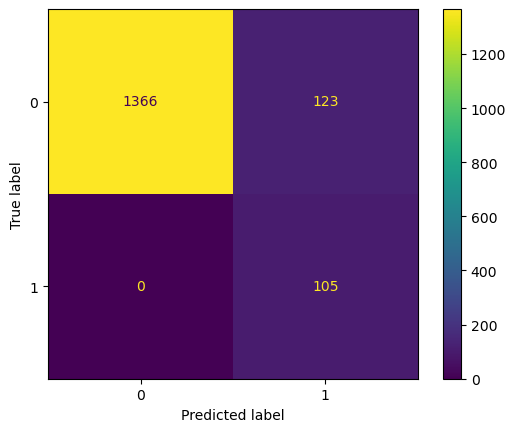

In [38]:
semi_labeled_predictions1 = selfTrainingModel.predict(x_test_semi_labeled)
report_ssl1 = classification_report(y_test, semi_labeled_predictions1, digits = 6)
report_ssl1_dict = classification_report(y_test, semi_labeled_predictions1, digits = 6, output_dict = True)
print(report_ssl1)
showConfusionMatrix(y_test, semi_labeled_predictions1)

In this context, self-training degrades performance through error propagation during iterative pseudo-labeling, where
  the model's low precision for "Malicious" instances (high false positives) generates incorrect pseudo-labels that
  reinforce errors in subsequent training cycles, ultimately reducing "Malicious" class precision and overall model
  effectiveness.

              precision    recall  f1-score   support

           0   1.000000  0.940900  0.969550      1489
           1   0.544041  1.000000  0.704698       105

    accuracy                       0.944793      1594
   macro avg   0.772021  0.970450  0.837124      1594
weighted avg   0.969965  0.944793  0.952104      1594



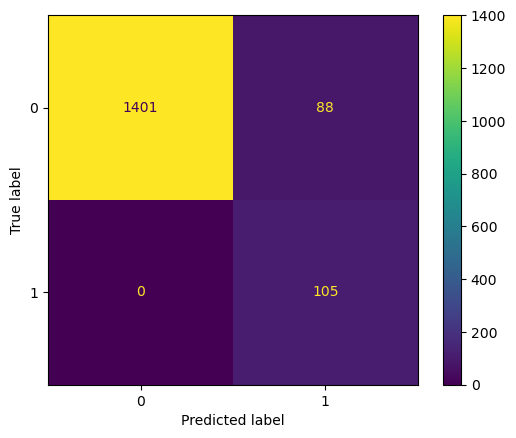

In [39]:
semi_labeled_predictions2 = modelPropagated.predict(x_test_semi_labeled)
report_ssl2 = classification_report(y_test, semi_labeled_predictions2, digits = 6)
report_ssl2_dict = classification_report(y_test, semi_labeled_predictions2, digits = 6, output_dict = True)
print(report_ssl2)
showConfusionMatrix(y_test, semi_labeled_predictions2)

The semi-supervised learning approach based on label propagation improves the classification performance of logistic regression on malicious instances, leading to fewer errors and reduced false positives, thus achieving better overall performance compared to the baseline model.

              precision    recall  f1-score   support

           0   1.000000  0.932169  0.964894      1489
           1   0.509709  1.000000  0.675241       105

    accuracy                       0.936637      1594
   macro avg   0.754854  0.966085  0.820068      1594
weighted avg   0.967704  0.936637  0.945814      1594



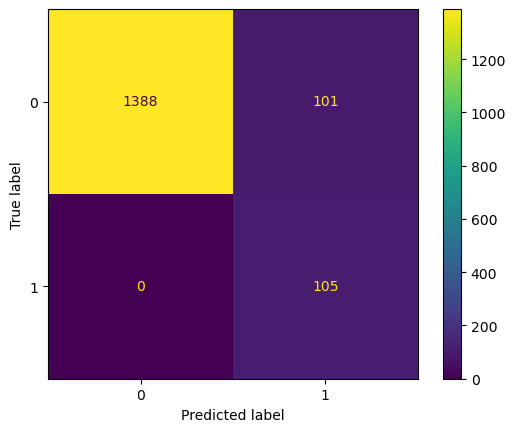

In [40]:
semi_labeled_predictions3 = modelSpreaded.predict(x_test_semi_labeled)
report_ssl3 = classification_report(y_test, semi_labeled_predictions3, digits = 6)
report_ssl3_dict = classification_report(y_test, semi_labeled_predictions3, digits = 6, output_dict = True)
print(report_ssl3)
showConfusionMatrix(y_test, semi_labeled_predictions3)

In this context, Label Spreading behaves very similarly to Label Propagation, although slightly worse. One possible explanation is that the labels assigned during the first iterations are already reliable. As a result, this over-smoothing effect can increase misclassifications and false positives, ultimately reducing overall model effectiveness.

#### Evaluating the not-tuned models
I am evaluating and comparing the performance differences between the four not-tuned models on the test set to assess which one generalizes better to unseen data.

              precision    recall  f1-score   support

           0   1.000000  0.898590  0.946586      1489
           1   0.410156  1.000000  0.581717       105

    accuracy                       0.905270      1594
   macro avg   0.705078  0.949295  0.764152      1594
weighted avg   0.961146  0.905270  0.922552      1594



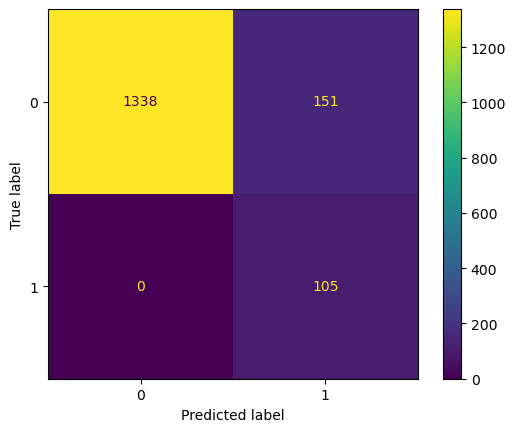

In [41]:
only_labeled_predictions = model_not_tuned.predict(x_test_only_labeled)
report_sl_not_tuned = classification_report(y_test, only_labeled_predictions, digits = 6)
report_sl_dict_not_tuned = classification_report(y_test, only_labeled_predictions, digits = 6, output_dict = True)
print(report_sl_not_tuned)
showConfusionMatrix(y_test, only_labeled_predictions)

The behavior is similar to the tuned model, but with a partial degradation in performance.


              precision    recall  f1-score   support

           0   1.000000  0.891202  0.942472      1489
           1   0.393258  1.000000  0.564516       105

    accuracy                       0.898369      1594
   macro avg   0.696629  0.945601  0.753494      1594
weighted avg   0.960033  0.898369  0.917575      1594



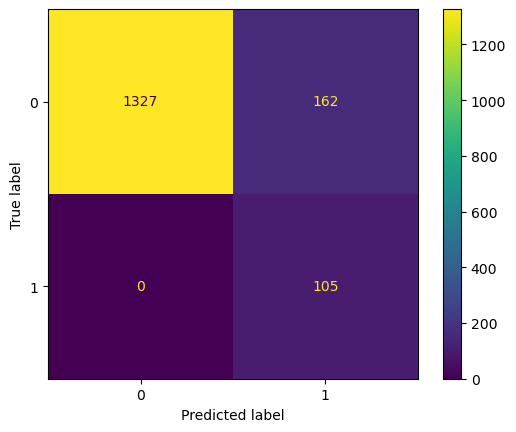

In [42]:
semi_labeled_predictions1 = selfTrainingModel_not_tuned.predict(x_test_semi_labeled)
report_ssl1_not_tuned = classification_report(y_test, semi_labeled_predictions1, digits = 6)
report_ssl1_dict_not_tuned = classification_report(y_test, semi_labeled_predictions1, digits = 6, output_dict = True)
print(report_ssl1_not_tuned)
showConfusionMatrix(y_test, semi_labeled_predictions1)

As before, the untuned self-training approach performs slightly worse than the baseline model.

              precision    recall  f1-score   support

           0   1.000000  0.911350  0.953619      1489
           1   0.443038  1.000000  0.614035       105

    accuracy                       0.917189      1594
   macro avg   0.721519  0.955675  0.783827      1594
weighted avg   0.963312  0.917189  0.931250      1594



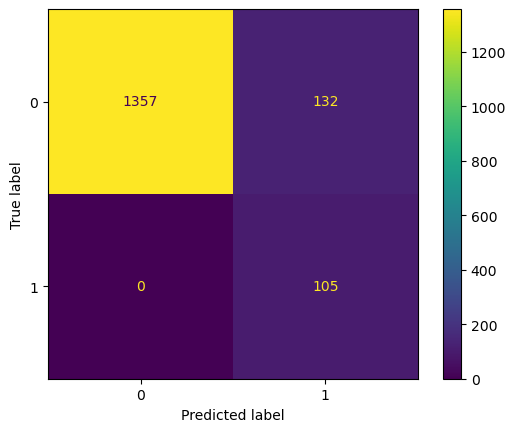

In [43]:
semi_labeled_predictions2 = modelPropagated_not_tuned.predict(x_test_semi_labeled)
report_ssl2_not_tuned = classification_report(y_test, semi_labeled_predictions2, digits = 6)
report_ssl2_dict_not_tuned = classification_report(y_test, semi_labeled_predictions2, digits = 6, output_dict = True)
print(report_ssl2_not_tuned)
showConfusionMatrix(y_test, semi_labeled_predictions2)

Label propagation improves the performance of the base model, similarly to what is observed with the tuned models.

              precision    recall  f1-score   support

           0   1.000000  0.911350  0.953619      1489
           1   0.443038  1.000000  0.614035       105

    accuracy                       0.917189      1594
   macro avg   0.721519  0.955675  0.783827      1594
weighted avg   0.963312  0.917189  0.931250      1594



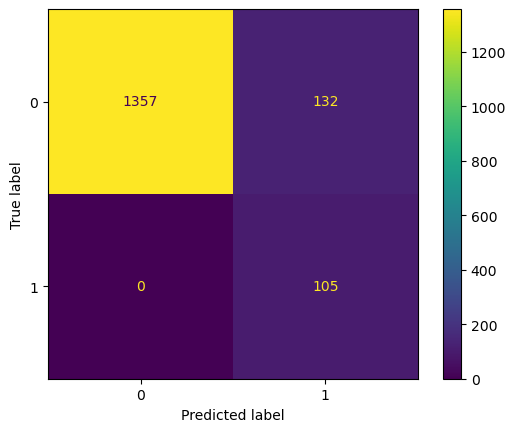

In [44]:
semi_labeled_predictions3 = modelSpreaded_not_tuned.predict(x_test_semi_labeled)
report_ssl3_not_tuned = classification_report(y_test, semi_labeled_predictions3, digits = 6)
report_ssl3_dict_not_tuned = classification_report(y_test, semi_labeled_predictions3, digits = 6, output_dict = True)
print(report_ssl3_not_tuned)
showConfusionMatrix(y_test, semi_labeled_predictions3)

An interesting observation is that the Label Spreading model behaves exactly the same as the Label Propagation model when no tuning is performed.

## Final considerations

Now I analyze and compare the performance of the models both in the case where they have been tuned and in the case where they are used as provided by scikit-learn.

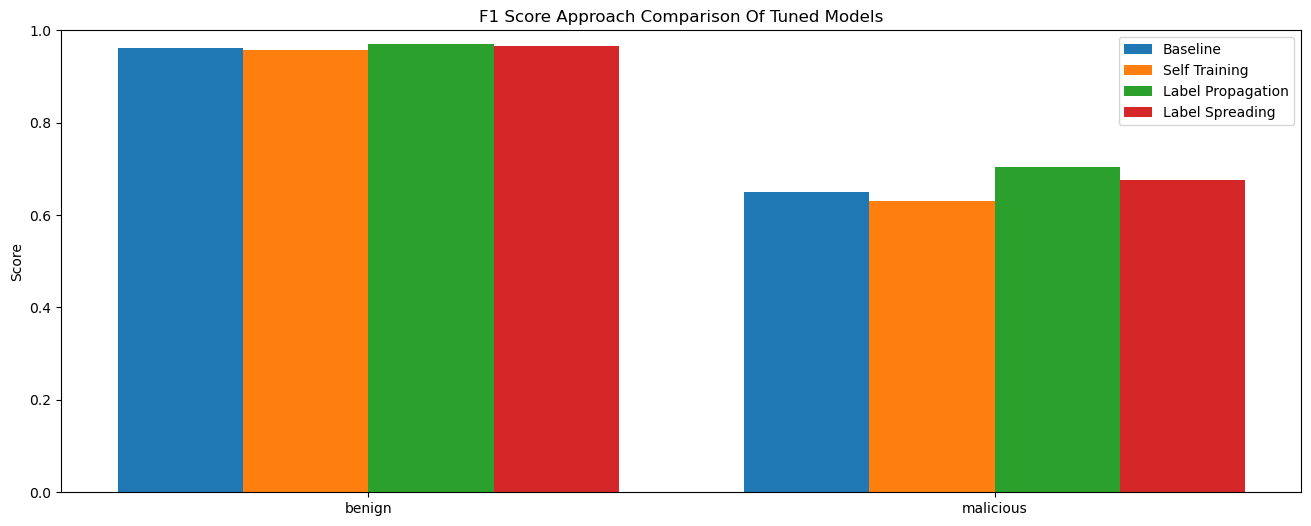

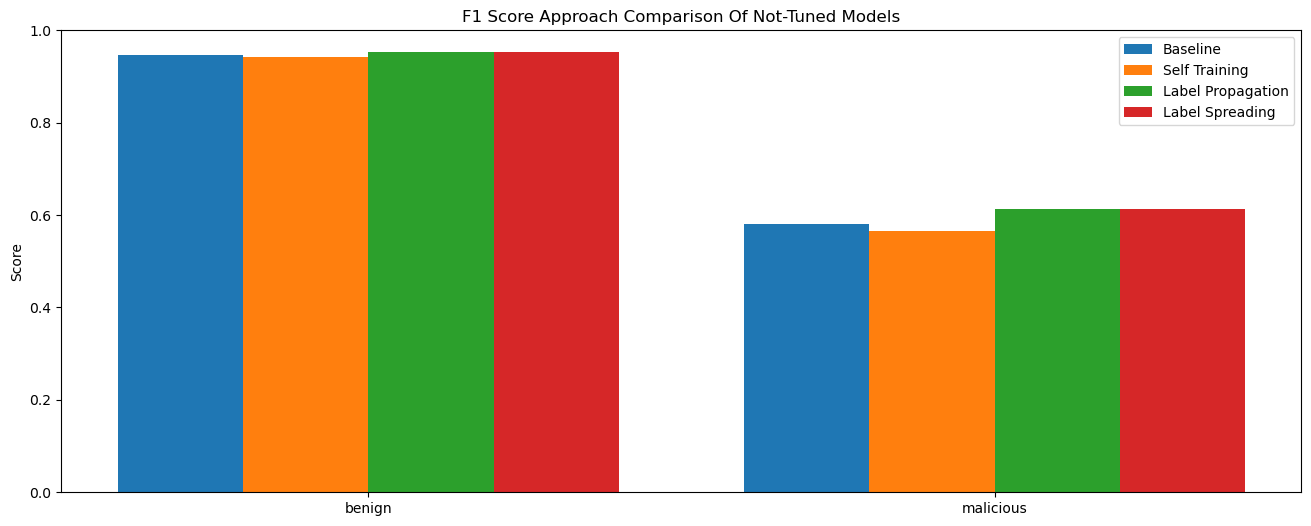

In [45]:
# function to show model comparison about f1-score of both classes
def showF1ComparisonPlot(report_sl_dict, report_ssl1_dict, report_ssl2_dict, report_ssl3_dict, suffix):
    labels = ['benign', 'malicious']
    x = np.array([0, 2])
    width = 0.4
    base = [report_sl_dict['0']['f1-score'], report_sl_dict['1']['f1-score']]
    sl = [report_ssl1_dict['0']['f1-score'], report_ssl1_dict['1']['f1-score']]
    lp = [report_ssl2_dict['0']['f1-score'], report_ssl2_dict['1']['f1-score']]
    ls = [report_ssl3_dict['0']['f1-score'], report_ssl3_dict['1']['f1-score']]

    plt.figure(figsize = (16, 6))
    plt.bar(x - 1.5 * width, base, width, label = 'Baseline')
    plt.bar(x - 0.5 * width, sl, width, label = 'Self Training')
    plt.bar(x + 0.5 * width, lp, width, label = 'Label Propagation')
    plt.bar(x + 1.5 * width, ls, width, label = 'Label Spreading')
    plt.xticks(x, labels)
    plt.ylim(0, 1)
    plt.ylabel("Score")
    plt.title(f"F1 Score Approach Comparison {suffix}")
    plt.legend()
    plt.show()

showF1ComparisonPlot(report_sl_dict, report_ssl1_dict, report_ssl2_dict, report_ssl3_dict, "Of Tuned Models")
showF1ComparisonPlot(report_sl_dict_not_tuned, report_ssl1_dict_not_tuned, report_ssl2_dict_not_tuned, report_ssl3_dict_not_tuned, "Of Not-Tuned Models")

In both cases, the semi-supervised learning approach based on Label Propagation performs best. It leads to a partial improvement in the F1 score for both benign and malicious instances. Label Spreading behaves very similarly to Label Propagation, although it performs slightly worse. A possible explanation is that the labels assigned during the first iterations are already highly reliable. Because of this, the additional smoothing introduced by Label Spreading may slightly alter predictions that were already correct, increasing some misclassifications and false positives, and therefore reducing the overall effectiveness of the model.

Self-training sits in the middle: it is the most straightforward wrapper-based approach, but in this case it does not provide significant benefits. It is also clear that a simple model such as logistic regression, when trained on a real-world, highly imbalanced dataset, can easily learn misleading patterns that end up propagating errors through the self-training semi-supervised process.

However, it is important to note that in this context the dataset is highly feature-rich and already heavily pre-engineered. Because of this, even having access to a portion of the labeled instances can already lead to strong model performance, as seen in the project. This naturally reduces the marginal benefit that semi-supervised learning methods can provide.

Another interesting observation is that, among the not-tuned models, the performance gap between the different semi-supervised learning approaches becomes smaller: they tend to behave more similarly in terms of performance, with less pronounced differences compared to what might be expected in other settings. In particular, Label Spreading and Label Propagation show almost identical behavior when no tuning is applied.

In more realistic scenarios, where datasets are less engineered and perhaps more balanced, semi-supervised learning approaches are likely to bring more substantial improvements, making such datasets more effectively exploitable for training machine learning models.

## Key takeaways

To summarize the three semi-supervised learning (SSL) approaches tested, the following conclusions can be drawn.

Self-training is a plug-and-play method for applying SSL. It can perform well when the underlying model is already able to clearly separate the classes in a classification setting, and when the dataset is relatively balanced and contains little noise. However, it is sensitive to error propagation: if the model makes wrong predictions early on, those errors can be reinforced in subsequent iterations.

Label Propagation leverages the intrinsic structure of the data through a graph-based algorithm. Even in the presence of class imbalance, it can still perform effectively, as observed in the project. However, it generally requires the data to be relatively clean, since noise can significantly affect the quality of label diffusion across the graph.

On the other hand, Label Spreading can be seen as an alternative to Label Propagation designed to handle noisier datasets. Because it performs a softer, more probabilistic diffusion of labels, it tends to smooth the influence of individual points and reduce the impact of potential labeling errors. In other words, it “spreads” labels in a more fluid way, which helps mitigate the effect of noise but can also slightly blur strong decision boundaries when the data is already clean.

Overall, each method shows strengths in different conditions: self-training is simple but sensitive to error accumulation, label propagation works well on structured but relatively clean data, and label spreading is more robust to noise but may sacrifice sharpness in well-separated datasets.